# Heart Disease Prediction from BRFSS2015 Health Indicators

## Project Aim
This project builds a machine learning pipeline that predicts whether someone has had heart
disease or a heart attack. It uses self-reported health indicators from the 2015 CDC
Behavioral Risk Factor Surveillance System (BRFSS) survey. The goal is to walk through a
complete, leakage-free ML workflow, from raw data to a final and honestly evaluated model,
rather than to build something ready for clinical use.

## Dataset
`heart_disease_health_indicators_BRFSS2015.csv`: 253,680 survey responses, 21 health and
lifestyle features (BMI, blood pressure, cholesterol, smoking, physical activity, and more),
and a binary target variable, `HeartDiseaseorAttack`.

## Team & Roles

| Student | Role | Name |
|---|---|---|
| Student 1 | Data Collection | Marcus Nathanael Priyan |
| Student 2 | Data Cleaning & EDA | Nilofarbanu Latifali Saiyad |
| Student 3 | Feature Engineering | Jaweria |
| Student 4 | Modeling | Aishwarya Suresh |
| Student 5 | Evaluation & Presentation | Saketh Rishi Nallagondla |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Duplicates are removed right after loading, before any split, so the same person's
# data can't end up in more than one split.
df = pd.read_csv('heart_disease_health_indicators_BRFSS2015.csv').drop_duplicates().reset_index(drop=True)

print("Data Shape:", df.shape)
df.head()

Data Shape: (229781, 22)


,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


# Phase 2: Train / Validation / Test Split

We split the data into three parts before any cleaning or scaling, to avoid data leakage:

- Train: 50%
- Validation: 25%
- Test: 25%

The validation set lets us compare models and pick the best one, while the test set stays
untouched until the final check.

In [2]:
X = df.drop(columns=['HeartDiseaseorAttack'])
y = df['HeartDiseaseorAttack']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=(1/3), random_state=42, stratify=y_temp
)

total = len(df)
print(f"Train Set:      {len(X_train)} rows ({len(X_train)/total*100:.1f}%)")
print(f"Validation Set: {len(X_val)} rows ({len(X_val)/total*100:.1f}%)")
print(f"Test Set:       {len(X_test)} rows ({len(X_test)/total*100:.1f}%)")

Train Set:      114890 rows (50.0%)
Validation Set: 57445 rows (25.0%)
Test Set:       57446 rows (25.0%)


# Phase 3: Data Audit & Cleaning

We check the training set for missing values and summary statistics before doing anything
else, so problems get caught early instead of building on bad data. Duplicates were already
removed before the split, so there's nothing left to remove here.

In [3]:
missing_vals = X_train.isnull().sum()
print("Missing values per column in X_train:")
print(missing_vals[missing_vals > 0] if missing_vals.sum() > 0 else "No missing values found!")

print(f"\nDuplicate rows in X_train: {X_train.duplicated().sum()}")

print("\nSummary Statistics of X_train:")
X_train.describe().T[['mean', 'std', 'min', '50%', 'max']]

Missing values per column in X_train:
No missing values found!

Duplicate rows in X_train: 274

Summary Statistics of X_train:


,mean,std,min,50%,max
HighBP,0.454835,0.497958,0.0,0.0,1.0
HighChol,0.440578,0.496459,0.0,0.0,1.0
CholCheck,0.959204,0.197817,0.0,1.0,1.0
BMI,28.721394,6.844713,12.0,27.0,98.0
Smoker,0.466420,0.498873,0.0,0.0,1.0
Stroke,0.044660,0.206557,0.0,0.0,1.0
Diabetes,0.323684,0.722814,0.0,0.0,2.0
PhysActivity,0.732962,0.442414,0.0,1.0,1.0
Fruits,0.612264,0.487236,0.0,1.0,1.0
Veggies,0.794429,0.404120,0.0,1.0,1.0


# Phase 4: Exploratory Data Analysis (EDA)

Before building anything, we look at the split sizes, target balance, BMI distribution, and
feature correlations to understand what we're working with. This is where we noticed the
target is heavily imbalanced, which shaped several decisions later on.

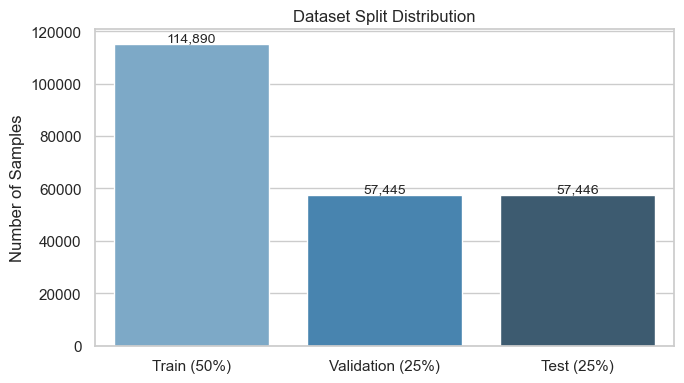

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 4))

split_sizes = {'Train (50%)': len(X_train), 'Validation (25%)': len(X_val), 'Test (25%)': len(X_test)}
ax = sns.barplot(x=list(split_sizes.keys()), y=list(split_sizes.values()), hue=list(split_sizes.keys()), palette='Blues_d', legend=False)

plt.title('Dataset Split Distribution')
plt.ylabel('Number of Samples')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

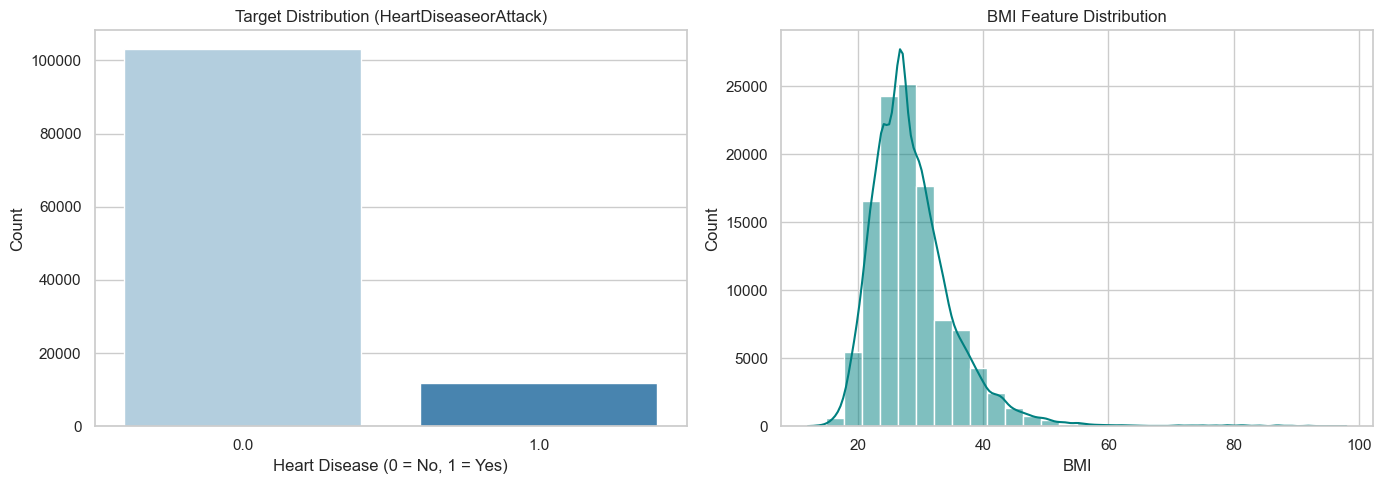

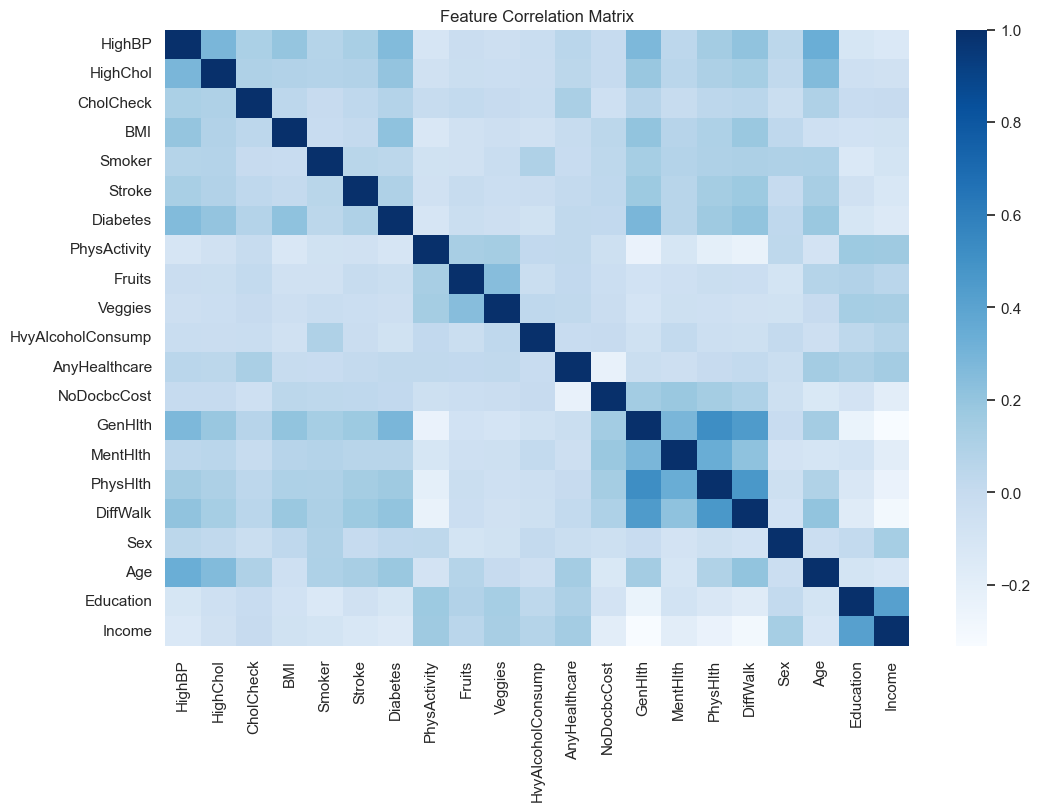

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(x=y_train, hue=y_train, ax=axes[0], palette='Blues', legend=False)
axes[0].set_title('Target Distribution (HeartDiseaseorAttack)')
axes[0].set_xlabel('Heart Disease (0 = No, 1 = Yes)')
axes[0].set_ylabel('Count')

sns.histplot(X_train['BMI'], kde=True, bins=30, ax=axes[1], color='teal')
axes[1].set_title('BMI Feature Distribution')
axes[1].set_xlabel('BMI')

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(X_train.corr(), cmap='Blues', annot=False, cbar=True)
plt.title('Feature Correlation Matrix')
plt.show()

# Phase 5: Exporting Cleaned Datasets

Saving all three splits to `Data/processed/` so later steps always use the same rows.

In [6]:
import os

processed_dir = 'Data/processed'
os.makedirs(processed_dir, exist_ok=True)

X_train.to_csv(f'{processed_dir}/X_train_clean.csv', index=False)
y_train.to_csv(f'{processed_dir}/y_train_clean.csv', index=False)
X_val.to_csv(f'{processed_dir}/X_val_clean.csv', index=False)
y_val.to_csv(f'{processed_dir}/y_val_clean.csv', index=False)
X_test.to_csv(f'{processed_dir}/X_test_clean.csv', index=False)
y_test.to_csv(f'{processed_dir}/y_test_clean.csv', index=False)

print("All clean datasets (train/val/test) successfully exported to 'Data/processed/' directory!")

All clean datasets (train/val/test) successfully exported to 'Data/processed/' directory!


# Feature Engineering

Raw columns alone don't always tell the full story, so we combined some of them into 10
new features that capture health risk patterns more directly.

- `ObesityFlag`: BMI of 30 or higher
- `CurrentSmokerFlag` / `FormerSmokerFlag`: current vs former smoking status
- `HeavyDrinkFlag`: heavy alcohol consumption
- `MentalHealthBurden`: poor mental health days
- `PhysicallyActiveFlag`: reported physical activity
- `CardiometabolicRiskScore`: combines obesity, high blood pressure, high cholesterol,
  diabetes, and stroke history into one risk score
- `AgeRiskTier`: age grouped into risk bands
- `HealthcareAccessRisk`: barriers to doctor visits
- `SocialIsolationProxy`: poor general health combined with high mental health burden

All features are applied the same way to train, validation, and test, through one shared
function, so the same logic is used everywhere.

In [7]:
def engineer_features(X):
    """Builds all engineered features, applied identically to train, validation, and test."""
    X = X.copy()

    # Obesity classification (BMI-based)
    X['ObesityFlag'] = (X['BMI'] >= 30).astype(int)

    # Tobacco exposure
    X['CurrentSmokerFlag'] = (X['Smoker'] == 1).astype(int)
    X['FormerSmokerFlag'] = (X['Smoker'] == 2).astype(int)

    # Alcohol misuse
    X['HeavyDrinkFlag'] = (X['HvyAlcoholConsump'] == 1).astype(int)

    # Mental health burden
    X['MentalHealthBurden'] = X.get('MentHlth', 0) + X.get('Depressed', 0)

    # Physical activity
    X['PhysicallyActiveFlag'] = (X['PhysActivity'] == 1).astype(int)

    # Merged cardiometabolic / metabolic syndrome risk score
    # Combines the two original overlapping scores into one: obesity, high BP,
    # high cholesterol, diabetes, and stroke history.
    X['CardiometabolicRiskScore'] = (
        X['ObesityFlag'] + X['HighBP'] + X['HighChol'] + X['Diabetes'] + X['Stroke']
    )

    # Age risk tiering
    X['AgeRiskTier'] = pd.cut(
        X['Age'], bins=[0, 34, 49, 64, 120],
        labels=['Low', 'Moderate', 'High', 'Very High']
    )

    # Healthcare access risk
    def _flag(col):
        val = X.get(col, 0)
        return (val == 1).astype(int) if isinstance(val, pd.Series) else int(val == 1)
    X['HealthcareAccessRisk'] = _flag('NoDocbcCost') + _flag('NoHealthInsurance')

    # Social isolation proxy
    X['SocialIsolationProxy'] = (
        (X['GenHlth'] >= 4).astype(int) + (X['MentHlth'] > 10).astype(int)
    )

    return X

X_train = engineer_features(X_train)
X_val = engineer_features(X_val)
X_test = engineer_features(X_test)

print("Feature engineering applied to Train, Validation, and Test sets.")
print(f"X_train shape: {X_train.shape} | X_val shape: {X_val.shape} | X_test shape: {X_test.shape}")

Feature engineering applied to Train, Validation, and Test sets.
X_train shape: (114890, 31) | X_val shape: (57445, 31) | X_test shape: (57446, 31)


# Phase 6: Model Building

Most of these features are already binary (0/1) or ordinal (ordered numbers like GenHlth,
Education, Income), so we scale them directly instead of one-hot encoding everything. This
keeps the feature count small and preserves order where it matters. The raw `Smoker` column
is dropped since it's redundant with `CurrentSmokerFlag` / `FormerSmokerFlag`. Three models
are trained together, compared on validation, and the best one is checked once on test.

In [8]:
from sklearn.preprocessing import StandardScaler

# AgeRiskTier is ordinal (Low < Moderate < High < Very High), so it's mapped to ordered
# integers instead of one-hot encoded, which would lose that order.
age_tier_map = {'Low': 0, 'Moderate': 1, 'High': 2, 'Very High': 3}
for split in (X_train, X_val, X_test):
    split['AgeRiskTier'] = split['AgeRiskTier'].map(age_tier_map)

# Raw Smoker is dropped: CurrentSmokerFlag and FormerSmokerFlag already capture it.
feature_cols = [c for c in X_train.columns if c != 'Smoker']

scaler = StandardScaler()
X_train_processed = pd.DataFrame(scaler.fit_transform(X_train[feature_cols]), columns=feature_cols, index=X_train.index)
X_val_processed = pd.DataFrame(scaler.transform(X_val[feature_cols]), columns=feature_cols, index=X_val.index)
X_test_processed = pd.DataFrame(scaler.transform(X_test[feature_cols]), columns=feature_cols, index=X_test.index)

print("Features processed successfully!")
print(f"Processed X_train shape: {X_train_processed.shape}")
print(f"Processed X_val shape:   {X_val_processed.shape}")
print(f"Processed X_test shape:  {X_test_processed.shape}")

Features processed successfully!
Processed X_train shape: (114890, 30)
Processed X_val shape:   (57445, 30)
Processed X_test shape:  (57446, 30)


## Training and Comparing the Models

KNN, Decision Tree, and Random Forest are trained together and compared on the validation
set using the same metrics.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

models = {
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
}

results = {}
val_predictions = {}
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_val_processed)
    results[name] = {
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred),
        'Recall': recall_score(y_val, y_pred),
        'F1-Score': f1_score(y_val, y_pred),
    }
    val_predictions[name] = y_pred
    print(f"{name} trained.")

comparison = pd.DataFrame(results).T
print("\n### Validation Set Comparison ###")
print(comparison.round(4))

KNN trained.
Decision Tree trained.
Random Forest trained.

### Validation Set Comparison ###
               Accuracy  Precision  Recall  F1-Score
KNN              0.8848     0.3641  0.1558    0.2183
Decision Tree    0.8343     0.2403  0.2801    0.2587
Random Forest    0.8936     0.4391  0.1106    0.1767


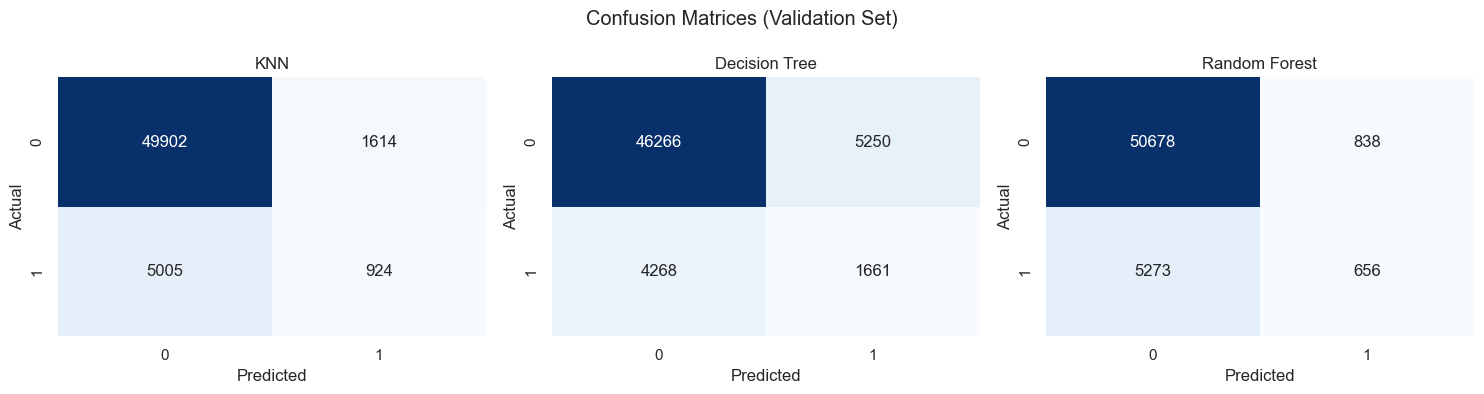

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, y_pred) in zip(axes, val_predictions.items()):
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices (Validation Set)')
plt.tight_layout()
plt.show()

# Phase 7: Model Selection & Final Test Evaluation

We pick the winner by validation F1-Score, then check it once on the test set.

Best model by Validation F1-Score: Decision Tree

### Decision Tree - Final Test Set Metrics ###
Accuracy: 0.8343
Precision: 0.2432
Recall: 0.2869
F1-Score: 0.2633


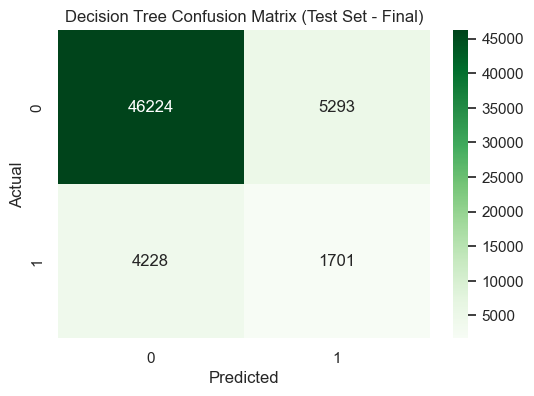

In [11]:
best_model_name = comparison['F1-Score'].idxmax()
best_model = models[best_model_name]
print(f"Best model by Validation F1-Score: {best_model_name}")

y_pred_test = best_model.predict(X_test_processed)
final_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_test),
    'Precision': precision_score(y_test, y_pred_test),
    'Recall': recall_score(y_test, y_pred_test),
    'F1-Score': f1_score(y_test, y_pred_test),
}
print(f"\n### {best_model_name} - Final Test Set Metrics ###")
for k, v in final_metrics.items():
    print(f"{k}: {v:.4f}")

cm_final = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens')
plt.title(f'{best_model_name} Confusion Matrix (Test Set - Final)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Phase 8: Evaluation & Conclusion

Accuracy alone is misleading here since only about 9% of people in the dataset have had
heart disease. A model that always predicts "No" would still score around 90% accuracy
while catching nothing. We compared models using F1-Score instead.

## Model Comparison (Validation Set)

| Model | Accuracy | Precision | Recall | F1-Score |
|---|---|---|---|---|
| KNN | 0.885 | 0.365 | 0.156 | 0.219 |
| **Decision Tree** | 0.834 | 0.240 | 0.280 | **0.259** |
| Random Forest | 0.894 | 0.439 | 0.111 | 0.177 |

Decision Tree was selected despite the lowest accuracy, since it caught more real cases
than the other two models. Test set results were close to validation (F1 0.263), so the
model isn't overfitting.

## Limitations

- Class imbalance (about 9% positive cases) means even our best model misses most real
  cases. None of the three models are strong enough for clinical use as-is.
- No hyperparameter tuning, class weighting, or resampling was used, to keep the pipeline
  simple and explainable.

## Conclusion

The pipeline works end to end and is free of data leakage, but its value here is
educational rather than clinical. With more time, addressing class imbalance would be the
biggest improvement.